# 📝 Week 5: Text Embedding & Representasi Semantik

Notebook ini mengeksplorasi representasi teks sebagai vektor padat (dense vectors) menggunakan model Sentence-BERT untuk analisis semantik artikel MBG.

## 🎯 Tujuan Pembelajaran:
1. Memahami konsep text embedding dan perbedaannya dengan TF-IDF
2. Menggunakan Sentence-BERT untuk mengkodekan kalimat/dokumen ke vektor
3. Menghitung kemiripan semantik antar artikel menggunakan cosine similarity
4. Memvisualisasikan ruang embedding dengan PCA dan t-SNE
5. Melakukan clustering tematik dengan K-Means

## 📦 Instalasi Dependencies

In [9]:
import warnings
warnings.filterwarnings('ignore')

%pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas openpyxl python-dotenv

print("✅ Semua library berhasil diinstall!")

Note: you may need to restart the kernel to use updated packages.
✅ Semua library berhasil diinstall!


In [11]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

# Load token dari file .env (pastikan sudah diisi di file .env)
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN or HF_TOKEN == "hf_xxx":
    raise ValueError("❌ HF_TOKEN belum diisi! Edit file .env dan isi dengan token asli dari https://huggingface.co/settings/tokens")

login(token=HF_TOKEN, add_to_git_credential=False)
print("✅ Hugging Face token berhasil dikonfigurasi!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Hugging Face token berhasil dikonfigurasi!


## 📚 Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Import libraries berhasil!")

✅ Import libraries berhasil!


---

## 1️⃣ Konsep Text Embedding

### 1.1 Kenapa Embedding?

| Representasi | Contoh | Kelemahan |
|---|---|---|
| Bag-of-Words | [1,0,1,0,1,...] | Sparser, tidak ada makna semantik |
| TF-IDF | [0.3,0,0.7,0,...] | Masih sparse, kata tidak saling berhubungan |
| **Word2Vec** | [0.12, -0.45, 0.87,...] | Kata per kata, tidak memahami kalimat |
| **Sentence-BERT** | [0.21, 0.34, -0.12,...] | **Dense, semantik-aware, level kalimat** |

### 1.2 Arsitektur Sentence-BERT

Sentence-BERT (Reimers & Gurevych, 2019) menggunakan **Siamese BERT** network:
```
Kalimat A → BERT Encoder → Pooling → Vektor A
Kalimat B → BERT Encoder → Pooling → Vektor B
                                → Cosine Similarity
```

---

## 2️⃣ Load Dataset

In [13]:
# Load dataset MBG
file_path = 'Dataset MBG.xlsx'
df_main = pd.read_excel(file_path, sheet_name='Main')
df_case = pd.read_excel(file_path, sheet_name='Case')

print("✅ Dataset berhasil dimuat!")
print(f"  Main: {len(df_main)} artikel")
print(f"  Case: {len(df_case)} artikel")
df_main[['Judul', 'Kota', 'Tone']].head(5)

✅ Dataset berhasil dimuat!
  Main: 32 artikel
  Case: 11 artikel


,Judul,Kota,Tone
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,Jakarta,Netral
1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,Jakarta,Netral
2,Target 20 Juta Penerima Makan Bergizi Gratis D...,Jakarta,Netral
3,"SD di Medan Gelar Makan Bergizi Gratis, Siswa:...","Medan, Sumatera Utara",Positif
4,"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luh...",Jakarta,Positif


In [14]:
# Siapkan teks konten untuk embedding
sentences = df_main['Judul'].fillna('').tolist()
contents = df_main['Konten'].fillna('').tolist()
titles = df_main['Judul'].fillna('Article').tolist()
categories = df_main['Tone'].fillna('Unknown').tolist()

print(f"\n✅ Siap mengkodekan {len(sentences)} artikel")
print(f"\nContoh judul:")
for i, s in enumerate(sentences[:3]):
    print(f"  [{i+1}] {s}")


✅ Siap mengkodekan 32 artikel

Contoh judul:
  [1] Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat
  [2] Sri Mulyani Ungkap Anggaran Program MBG Lebih dari Rp 300 Triliun di 2026
  [3] Target 20 Juta Penerima Makan Bergizi Gratis Dikejar, Anggaran Sudah Rp 8,2 Triliun


---

## 3️⃣ Generate Sentence Embeddings

### 3.1 Load Model Sentence-BERT Multibahasa

In [15]:
# Load model multilingual yang mendukung Bahasa Indonesia
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
print(f"⏳ Loading model '{model_name}'...")
model = SentenceTransformer(model_name)
print("✅ Model berhasil dimuat!")
print(f"  Max sequence length: {model.max_seq_length}")
print(f"  Embedding dimension: {model.get_sentence_embedding_dimension()}")

⏳ Loading model 'paraphrase-multilingual-MiniLM-L12-v2'...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4187.32it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model berhasil dimuat!
  Max sequence length: 128
  Embedding dimension: 384


### 3.2 Encode Judul Artikel

In [16]:
# Encode semua judul artikel
print("⏳ Mengkodekan judul artikel...")
embeddings = model.encode(sentences, show_progress_bar=True)

print(f"\n✅ Embeddings selesai dibuat!")
print(f"  Shape: {embeddings.shape}")
print(f"  {embeddings.shape[0]} artikel × {embeddings.shape[1]} dimensi")

⏳ Mengkodekan judul artikel...


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.45it/s]


✅ Embeddings selesai dibuat!
  Shape: (32, 384)
  32 artikel × 384 dimensi


---

## 4️⃣ Cosine Similarity

Cosine similarity mengukur sudut antara dua vektor:
$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

Nilai berkisar 0 (berbeda total) hingga 1 (identik).

### 4.1 Hitung Similarity Matrix

In [17]:
# Hitung cosine similarity antar semua dokumen
similarity_matrix = cosine_similarity(embeddings)

print("✅ Similarity matrix dihitung!")
print(f"  Shape: {similarity_matrix.shape}")
print(f"  Nilai min: {similarity_matrix.min():.4f}")
print(f"  Nilai max (diagonal): {similarity_matrix.max():.4f}")
print(f"  Rata-rata off-diagonal: {similarity_matrix[~np.eye(len(similarity_matrix), dtype=bool)].mean():.4f}")

✅ Similarity matrix dihitung!
  Shape: (32, 32)
  Nilai min: 0.0778
  Nilai max (diagonal): 1.0000
  Rata-rata off-diagonal: 0.4784


### 4.2 Visualisasi Heatmap Similarity

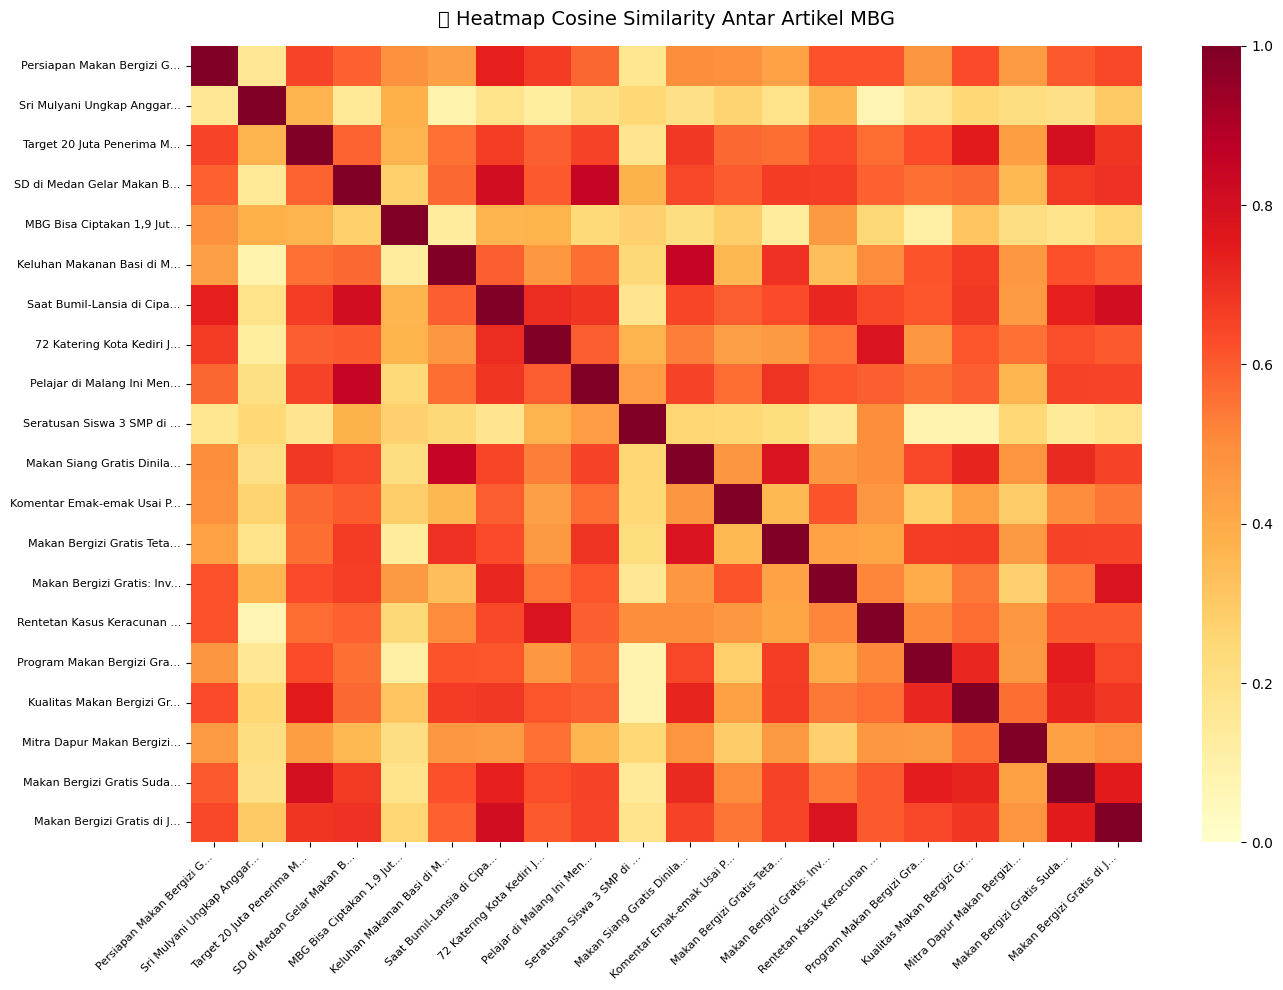

✅ Heatmap tersimpan sebagai 'Dataset_MBG_Cosine_Similarity_Heatmap.png'


In [31]:
# Heatmap cosine similarity
n = min(20, len(sentences))  # tampilkan maksimal 20 artikel
short_titles = [t[:25] + '...' if len(t) > 25 else t for t in titles[:n]]

plt.figure(figsize=(14, 10))
sns.heatmap(
    similarity_matrix[:n, :n],
    xticklabels=short_titles,
    yticklabels=short_titles,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    annot=True if n <= 10 else False,
    fmt='.2f' if n <= 10 else ''
)
plt.title('🔥 Heatmap Cosine Similarity Antar Artikel MBG', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('Dataset_MBG_Cosine_Similarity_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap tersimpan sebagai 'Dataset_MBG_Cosine_Similarity_Heatmap.png'")

### 4.3 Cari Pasangan Artikel Paling Mirip

In [19]:
# Cari top-5 pasangan artikel paling mirip (non-diagonal)
sim_pairs = []
for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):
        sim_pairs.append((i, j, similarity_matrix[i, j]))

sim_pairs.sort(key=lambda x: x[2], reverse=True)

print("📊 Top 5 pasangan artikel paling mirip secara semantik:")
print(f"{'Rank':<5} {'Sim Score':<12} {'Artikel A':<45} {'Artikel B':<45}")
print("-" * 110)
for rank, (i, j, score) in enumerate(sim_pairs[:5], 1):
    a = titles[i][:42] + '...' if len(titles[i]) > 42 else titles[i]
    b = titles[j][:42] + '...' if len(titles[j]) > 42 else titles[j]
    print(f"{rank:<5} {score:<12.4f} {a:<45} {b:<45}")

📊 Top 5 pasangan artikel paling mirip secara semantik:
Rank  Sim Score    Artikel A                                     Artikel B                                    
--------------------------------------------------------------------------------------------------------------
1     0.9114       Makan Siang Gratis Dinilai Cuma Bisa Jadi ... Luhut Sebut Anak-anak Menikmati Makan Berg...
2     0.8514       Keluhan Makanan Basi di Menu Makan Bergizi... Makan Siang Gratis Dinilai Cuma Bisa Jadi ...
3     0.8512       SD di Medan Gelar Makan Bergizi Gratis, Si... Pelajar di Malang Ini Menangis Saat Terima...
4     0.8312       Kualitas Makan Bergizi Gratis Bakal Dikont... Seberapa Konsisten Program Makan Bergizi G...
5     0.8115       Saat Bumil-Lansia di Ciparay Bandung Menda... Makan Bergizi Gratis di Jakarta Dibagikan ...


---

## 5️⃣ Visualisasi Ruang Embedding

Dimensi embedding (384) terlalu tinggi untuk divisualisasikan — kita reduksi ke 2D menggunakan **PCA** dan **t-SNE**.

### 5.1 Reduksi Dimensi dengan PCA

In [20]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

print(f"✅ PCA selesai!")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total explained: {pca.explained_variance_ratio_.sum():.2%}")

✅ PCA selesai!
  Explained variance ratio: [0.19728027 0.11677284]
  Total explained: 31.41%


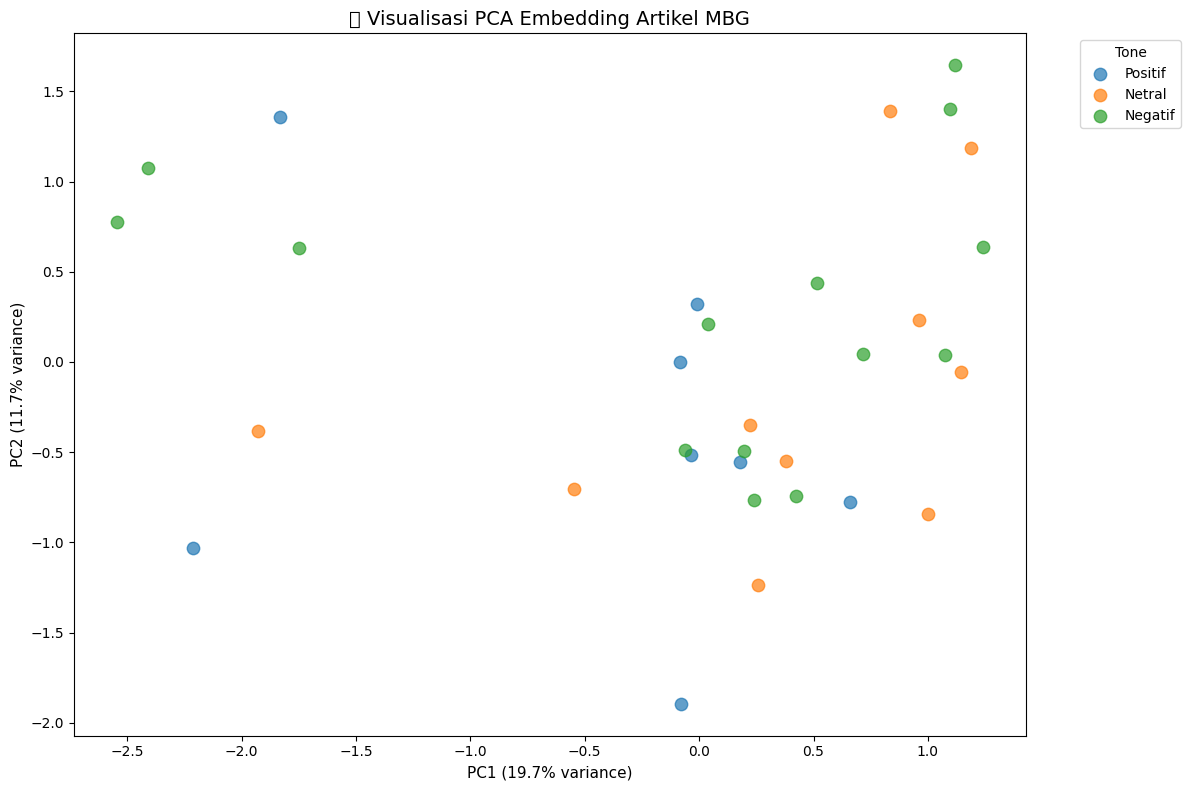

✅ PCA plot tersimpan sebagai 'Dataset_MBG_PCA_Embedding.png'


In [22]:
# Plot PCA
fig, ax = plt.subplots(figsize=(12, 8))

unique_cats = list(set(categories))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_color = {cat: colors[i] for i, cat in enumerate(unique_cats)}

for cat in unique_cats:
    mask = [c == cat for c in categories]
    pts = embeddings_pca[mask]
    ax.scatter(pts[:, 0], pts[:, 1], label=cat, alpha=0.7, s=80)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('📐 Visualisasi PCA Embedding Artikel MBG', fontsize=14)
ax.legend(title='Tone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Dataset_MBG_PCA_Embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA plot tersimpan sebagai 'Dataset_MBG_PCA_Embedding.png'")

### 5.2 Reduksi Dimensi dengan t-SNE

In [24]:
# t-SNE 2D
perplexity_val = min(30, len(embeddings) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings)

print(f"✅ t-SNE selesai!")
print(f"  Perplexity: {perplexity_val}")

✅ t-SNE selesai!
  Perplexity: 30


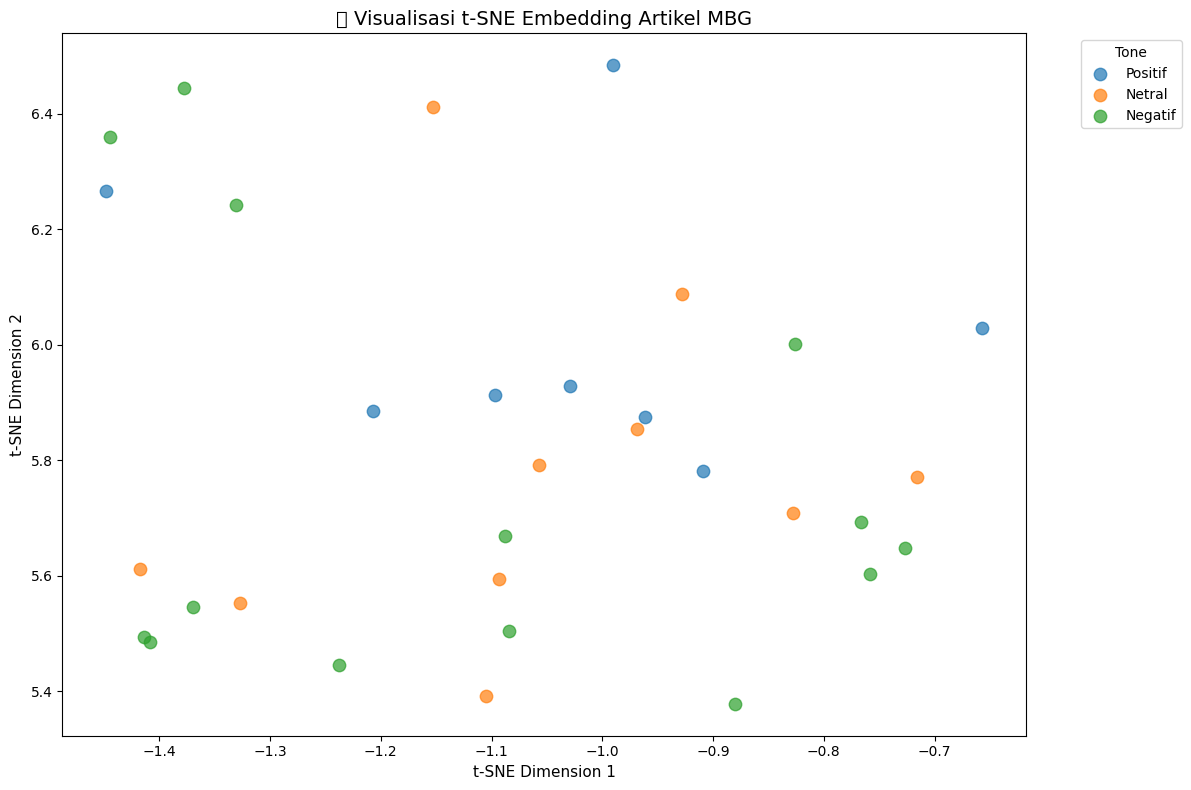

✅ t-SNE plot tersimpan sebagai 'Dataset_MBG_tSNE_Embedding.png'


In [26]:
# Plot t-SNE
fig, ax = plt.subplots(figsize=(12, 8))

for cat in unique_cats:
    mask = [c == cat for c in categories]
    pts = embeddings_tsne[np.array(mask)]
    ax.scatter(pts[:, 0], pts[:, 1], label=cat, alpha=0.7, s=80)

ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.set_title('🔵 Visualisasi t-SNE Embedding Artikel MBG', fontsize=14)
ax.legend(title='Tone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Dataset_MBG_tSNE_Embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE plot tersimpan sebagai 'Dataset_MBG_tSNE_Embedding.png'")

---

## 6️⃣ Clustering Tematik dengan K-Means

In [27]:
# K-Means clustering (3 cluster)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Label heuristik untuk cluster
cluster_names = {0: 'Challenge', 1: 'Solution', 2: 'Impact'}

df_main = df_main.copy()
df_main['cluster_id'] = cluster_labels
df_main['cluster_name'] = [cluster_names[l] for l in cluster_labels]

print("✅ K-Means clustering selesai!")
print("\n📊 Distribusi artikel per cluster:")
for cid, cname in cluster_names.items():
    count = (cluster_labels == cid).sum()
    print(f"  Cluster {cid} - {cname}: {count} artikel")

✅ K-Means clustering selesai!

📊 Distribusi artikel per cluster:
  Cluster 0 - Challenge: 12 artikel
  Cluster 1 - Solution: 14 artikel
  Cluster 2 - Impact: 6 artikel


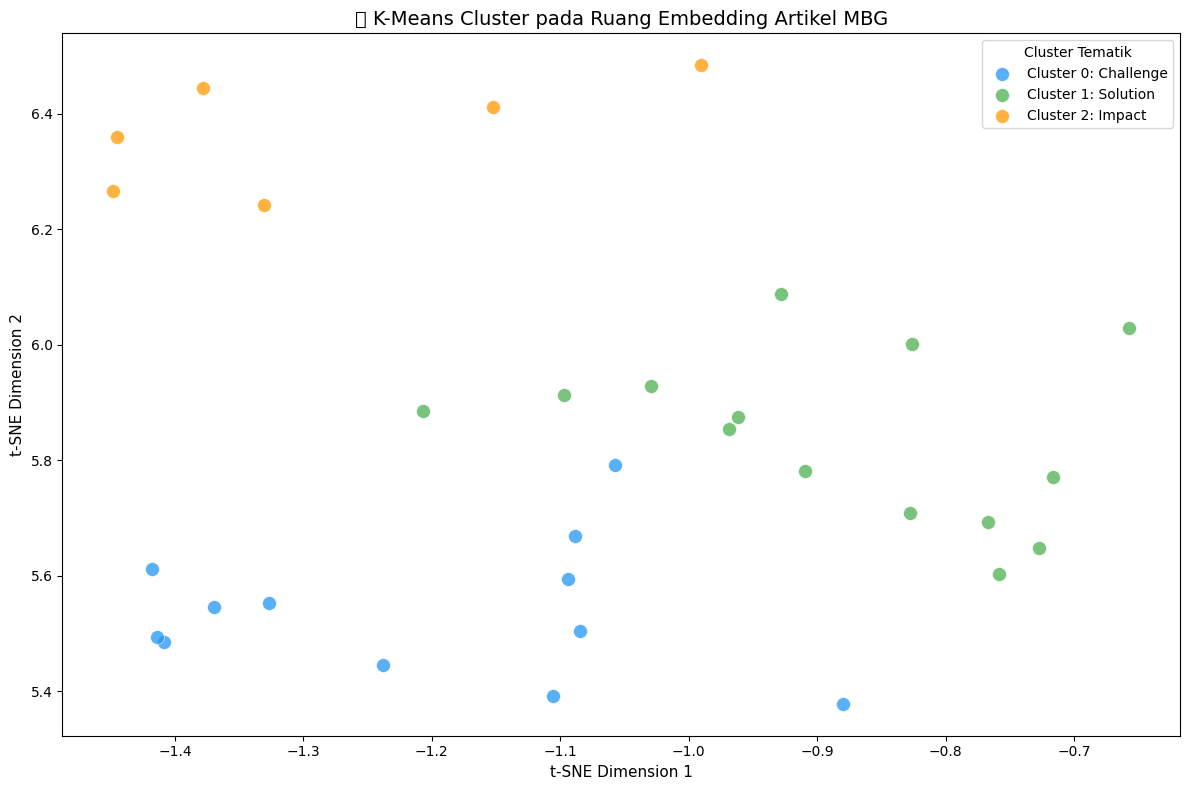

✅ Cluster plot tersimpan sebagai 'Dataset_MBG_KMeans_Cluster.png'


In [29]:
# Visualisasi cluster pada t-SNE
cluster_colors = ['#2196F3', '#4CAF50', '#FF9800']
fig, ax = plt.subplots(figsize=(12, 8))

for cid, cname in cluster_names.items():
    mask = cluster_labels == cid
    pts = embeddings_tsne[mask]
    ax.scatter(pts[:, 0], pts[:, 1], label=f'Cluster {cid}: {cname}',
               color=cluster_colors[cid], alpha=0.75, s=100, edgecolors='white', linewidths=0.5)

ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.set_title('🎯 K-Means Cluster pada Ruang Embedding Artikel MBG', fontsize=14)
ax.legend(title='Cluster Tematik', fontsize=10)
plt.tight_layout()
plt.savefig('Dataset_MBG_KMeans_Cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster plot tersimpan sebagai 'Dataset_MBG_KMeans_Cluster.png'")

In [30]:
# Tampilkan sampel artikel per cluster
print("📋 Sampel artikel per cluster tema:")
for cid, cname in cluster_names.items():
    print(f"\n--- Cluster {cid}: {cname} ---")
    samples = df_main[df_main['cluster_id'] == cid]['Judul'].head(3).values
    for j, s in enumerate(samples, 1):
        print(f"  {j}. {s[:80]}")

📋 Sampel artikel per cluster tema:

--- Cluster 0: Challenge ---
  1. Target 20 Juta Penerima Makan Bergizi Gratis Dikejar, Anggaran Sudah Rp 8,2 Tril
  2. Keluhan Makanan Basi di Menu Makan Bergizi Gratis, Apa Dampaknya jika Dikonsumsi
  3. Makan Siang Gratis Dinilai Cuma Bisa Jadi Penopang Tambahan Gizi Anak

--- Cluster 1: Solution ---
  1. Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaa
  2. SD di Medan Gelar Makan Bergizi Gratis, Siswa: Makanannya Enak, Pedas Manis Gitu
  3. Saat Bumil-Lansia di Ciparay Bandung Mendapat Makanan Bergizi Gratis

--- Cluster 2: Impact ---
  1. Sri Mulyani Ungkap Anggaran Program MBG Lebih dari Rp 300 Triliun di 2026
  2. MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luhut: Dampak Luar Biasa pada Pertumb
  3. Seratusan Siswa 3 SMP di Mlati Diduga Keracunan MBG, Polisi Periksa SPPG


---

## 📝 Kesimpulan

- 🎯 **Text Embedding** mengkonversi teks menjadi vektor padat yang mampu menangkap makna semantik — berbeda dengan TF-IDF yang hanya menghitung statistik kemunculan kata.
- 📊 **Cosine Similarity** memungkinkan pengukuran kemiripan semantik antar artikel secara kuantitatif; artikel yang membahas topik serupa memiliki nilai similarity tinggi.
- 🔧 **PCA dan t-SNE** memvisualisasikan ruang berdimensi tinggi (384D) menjadi 2D untuk analisis klaster dan pola distribusi tematik.
- 📂 **K-Means Clustering** mengelompokkan artikel ke dalam tema-tema laten (Challenge/Solution/Impact) yang mencerminkan framing berita MBG di media Indonesia.

---

## 📚 Referensi

- Mikolov, T., et al. (2013). Efficient estimation of word representations in vector space. *arXiv preprint arXiv:1301.3781*.
- Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. *EMNLP*.
- Van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *JMLR, 9*, 2579–2605.
- Sentence-Transformers docs: [https://www.sbert.net/](https://www.sbert.net/)

---